# Long-term OPE STAR Simulation: Varying sample ratios

In this notebook, we compare the estimation accuracy of four estimation methods with varying sample ratios drawn independently from the historical and short-term experiment datasets.

In [146]:
import time
import warnings
warnings.filterwarnings('ignore')

import importlib
import numpy as np
import pandas as pd
from pandas import DataFrame
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils import check_random_state

# Reload modules to get latest changes
import dataset
importlib.reload(dataset)
from dataset import STARDataLoader
import estimation
importlib.reload(estimation)
run_all = estimation.run_all

In [147]:
import seaborn as sns

sns.set_theme(style='white')

# 1. 提案手法の上下限（lower / upper）のキーを末尾に追加
method_list = [
    "long_term_experiment", 
    "long_term_ci", 
    "typical_ope_ips", 
    "typical_ope_dr", 
    "long_term_ope",
    "proposed_lope_gmsm_lower",  # 追加：提案手法の下限
    "proposed_lope_gmsm_upper"   # 追加：提案手法の上限
]

# 2. 論文やスライドに表示される凡例名を設定
legend = [
    "Long-term Experiment (Skyline)", 
    "Long-term CI", 
    "OPE (IPS)", 
    "OPE (DR)", 
    "LOPE (Ours)",
    "Proposed LOPE-GMSM (Upper Bound)"  # 追加
]

# 3. カラーパレットを拡張（提案手法の上下限を「紫・ピンク」系統に割り当て、不確実性の幅だと直感的にわかるように指定）
palette = [
    'tab:grey',  # long_term_experiment (グレー)
    '#FF6437',   # long_term_ci (オレンジ)
    '#509BF5',   # typical_ope_ips (青)
    '#F037A5',   # typical_ope_dr (マゼンタ)
    '#4B917D',   # long_term_ope (緑)
    '#7209B7',   # proposed_lope_gmsm_lower (濃い紫)
    '#B5179E'    # proposed_lope_gmsm_upper (明るい紫)
]

y_label_dict = {
    "se": "MSE", "bias": "Squared Bias", "variance": "Variance", "selection": "% Right Selection",
    "norm_se": "Norm-MSE", "norm_bias": "Norm-Squared Bias", "norm_variance": "Norm-Variance",
    "rel_se": "Relative MSE", "rel_bias": "Relative Squared Bias", "rel_variance": "Relative Variance", "rel_selection": "Rel-% Right Selection"
}

In [148]:
### experiment configurations for ACTG175 real data ###
n_sims = 100  # number of simulation runs (reduced for real data)
n_actions = 2  # number of treatment groups (0=historical, 1=experimental)
x_dim = 9  # feature dimension (gender, ethnicity, lunchk, schoolk, degreek, experiencek, ladderk, tethnicityk, readk, mathk)
a_dim = 2  # action feature dimension
s_dim = 1  # short-term reward dimension (read1)

# For real data, lambda is not used in the same way as synthetic data
lambda_ = 0.5  # contribution of the short-term rewards (for comparison)
reward_std = 5.0 # level of noise on the long-term reward
reward_type = "continuous"  # time-to-event is continuous

# Data ratios to vary independently within each treatment pool
beta, k, eps = 1, 3, 0.1 # define baseline and new policies
percentages = [0.20, 0.40, 0.60, 0.80, 1.00]
base_n_data = 2408  # base sample size for each pool

In [149]:
result_df_list = []

# 1. データローダーの初期化
dataset = STARDataLoader(
    csv_path="STAR/STAR.csv",
    preprocess_model='gbdt',  # または 'linear'
)
# True value の取得（前回のダミープレースホルダーではなく、データローダー内の真の報酬平均を使用）
true_value_of_baseline_policy = dataset.calc_policy_value_beta(beta=beta) # ベータ方策 pi_b の真の価値
true_value_of_new_policy = dataset.calc_policy_value_eps(k=k, eps=eps) # 人工的に設計した新方策 pi_e の真の価値
is_new_policy_better = int(true_value_of_baseline_policy < true_value_of_new_policy)
is_new_policy_better = is_new_policy_better - (1 - is_new_policy_better)

print(f"True Baseline Value: {round(true_value_of_baseline_policy, 3)}, True New Policy Value: {round(true_value_of_new_policy, 3)}")

# データサイズ（割合）のループ
for ratio in percentages:
    estimated_baseline_policy_value_list = []
    estimated_new_policy_value_list = []
    estimated_comparison_list = []

    # シミュレーションループ
    for sim_idx in tqdm(range(n_sims), desc=f"ratio={int(round(100 * ratio))}%..."):
        n_data = int(base_n_data * ratio)
        D_H = dataset.generate_dataset(n_data=n_data, beta=beta, k=k, eps=eps, baseline=True) # historical data generated by a baseline policy
        D_E_0 = dataset.generate_dataset(n_data, beta=beta, baseline=True) # short-term experiment data generated by a baseline policy
        D_E_1 = dataset.generate_dataset(n_data, k=k, eps=eps, baseline=False) # short-term experiment data generated by a new policy

        # 評価関数の実行（run_allにD_Hと、新旧両方の確率が入ったD_Eをそのまま渡す）
        # ※run_allの内部で、D_E['pi_b']を用いたベースライン評価と、D_E['pi_e']を用いた新方策評価が一括で行われます。
        estimated_values_of_baseline, estimated_values_of_new_policy, estimated_comparison = run_all(D_H,  [D_E_0, D_E_1], gamma=1.2)
        
        estimated_baseline_policy_value_list.append(estimated_values_of_baseline)
        estimated_new_policy_value_list.append(estimated_values_of_new_policy)
        estimated_comparison_list.append(estimated_comparison)


    result_df = (
        pd.concat([
            pd.DataFrame(estimated_baseline_policy_value_list).stack(),
            pd.DataFrame(estimated_new_policy_value_list).stack(),
            pd.DataFrame(estimated_comparison_list).stack(),
        ], axis=1).reset_index(1).rename(columns={"level_1": "est", 0: "base_value", 1: "value", 2: "selection"})
    )
    result_df["ratio"] = ratio
    result_df["n_data_h"] = n_data
    result_df["n_data_e"] = n_data
    result_df["true_value"] = true_value_of_new_policy
    result_df["se"] = (result_df.value - true_value_of_new_policy) ** 2
    result_df["bias"] = 0.0
    result_df["variance"] = 0.0
    result_df["selection"] *= is_new_policy_better
    result_df["selection"] = result_df["selection"] == 1

    sample_mean = pd.DataFrame(result_df.groupby(["est"]).mean().value).reset_index()
    for est_ in sample_mean["est"]:
        estimates = result_df.loc[result_df["est"] == est_, "value"].values
        mean_estimates = sample_mean.loc[sample_mean["est"] == est_, "value"].values
        mean_estimates = np.ones_like(estimates) * mean_estimates
        result_df.loc[result_df["est"] == est_, "bias"] = (true_value_of_new_policy - mean_estimates) ** 2
        result_df.loc[result_df["est"] == est_, "variance"] = (estimates - mean_estimates) ** 2

    method_summary = (
        result_df.groupby("est")[["se", "bias", "variance", "selection"]]
        .mean()
        .rename(columns={"se": "mse", "selection": "right_selection_rate"})
    )

    # ログ出力用
    print(f"\n=== data ratio: {int(round(100 * ratio))}% (historical={n_data}, experimental={n_data}) ===")
    print(method_summary.round(4).to_string())

    result_df_list.append(result_df)

result_df = pd.concat(result_df_list).reset_index(drop=True)

Loaded 11598 samples from STAR/STAR.csv
Data shapes: x=(2748, 6), a=(2748,), s=(2748, 1), r=(2748,)
True Baseline Value: 1261.199, True New Policy Value: 1255.321


ratio=20%...: 100%|██████████| 100/100 [03:04<00:00,  1.85s/it]



=== data ratio: 20% (historical=481, experimental=481) ===
                               mse      bias  variance  right_selection_rate
est                                                                         
long_term_ci               13.9228    1.2659   12.6569                  0.49
long_term_experiment       12.9792    3.9112    9.0680                  0.49
long_term_ope              15.6017    0.1370   15.4647                  0.88
proposed_lope_gmsm_lower  110.3483   94.5867   15.7616                  0.89
proposed_lope_gmsm_upper  126.2782  109.9608   16.3174                  0.85
typical_ope_dr             33.4264   11.8553   21.5711                  0.98


ratio=40%...: 100%|██████████| 100/100 [02:56<00:00,  1.76s/it]



=== data ratio: 40% (historical=963, experimental=963) ===
                               mse      bias  variance  right_selection_rate
est                                                                         
long_term_ci               13.5559    6.0180    7.5379                  0.56
long_term_experiment       12.7433    6.0500    6.6933                  0.47
long_term_ope               8.1111    0.0168    8.0943                  0.97
proposed_lope_gmsm_lower  111.0420  102.8991    8.1429                  0.97
proposed_lope_gmsm_upper  106.3357   97.8118    8.5239                  0.96
typical_ope_dr             18.3236    7.5358   10.7879                  1.00


...


=== data ratio: 60% (historical=1444, experimental=1444) ===
                               mse      bias  variance  right_selection_rate
est                                                                         
long_term_ci               10.6264    4.9131    5.7133                  0.49
long_term_experiment       10.0361    5.3265    4.7095                  0.39
long_term_ope               5.7647    0.0655    5.6991                  1.00
proposed_lope_gmsm_lower   99.6855   94.0751    5.6104                  1.00
proposed_lope_gmsm_upper  110.5563  104.4597    6.0966                  1.00
typical_ope_dr             10.4724    2.8357    7.6367                  1.00


ratio=80%...: 100%|██████████| 100/100 [03:11<00:00,  1.92s/it]



=== data ratio: 80% (historical=1926, experimental=1926) ===
                               mse      bias  variance  right_selection_rate
est                                                                         
long_term_ci                7.2619    4.5081    2.7538                  0.54
long_term_experiment        9.7492    7.2377    2.5115                  0.59
long_term_ope               3.3541    0.2038    3.1502                  1.00
proposed_lope_gmsm_lower   92.1951   88.9541    3.2409                  1.00
proposed_lope_gmsm_upper  110.2760  106.9702    3.3058                  1.00
typical_ope_dr              5.4683    1.3309    4.1374                  1.00


ratio=100%...: 100%|██████████| 100/100 [03:18<00:00,  1.99s/it]


=== data ratio: 100% (historical=2408, experimental=2408) ===
                               mse      bias  variance  right_selection_rate
est                                                                         
long_term_ci                7.2626    4.8515    2.4110                  0.54
long_term_experiment        8.4938    6.3508    2.1429                  0.60
long_term_ope               2.7485    0.5570    2.1916                  1.00
proposed_lope_gmsm_lower   85.0582   82.7841    2.2740                  1.00
proposed_lope_gmsm_upper  114.7982  112.4627    2.3355                  1.00
typical_ope_dr              3.4969    0.4192    3.0777                  1.00


## Visualization

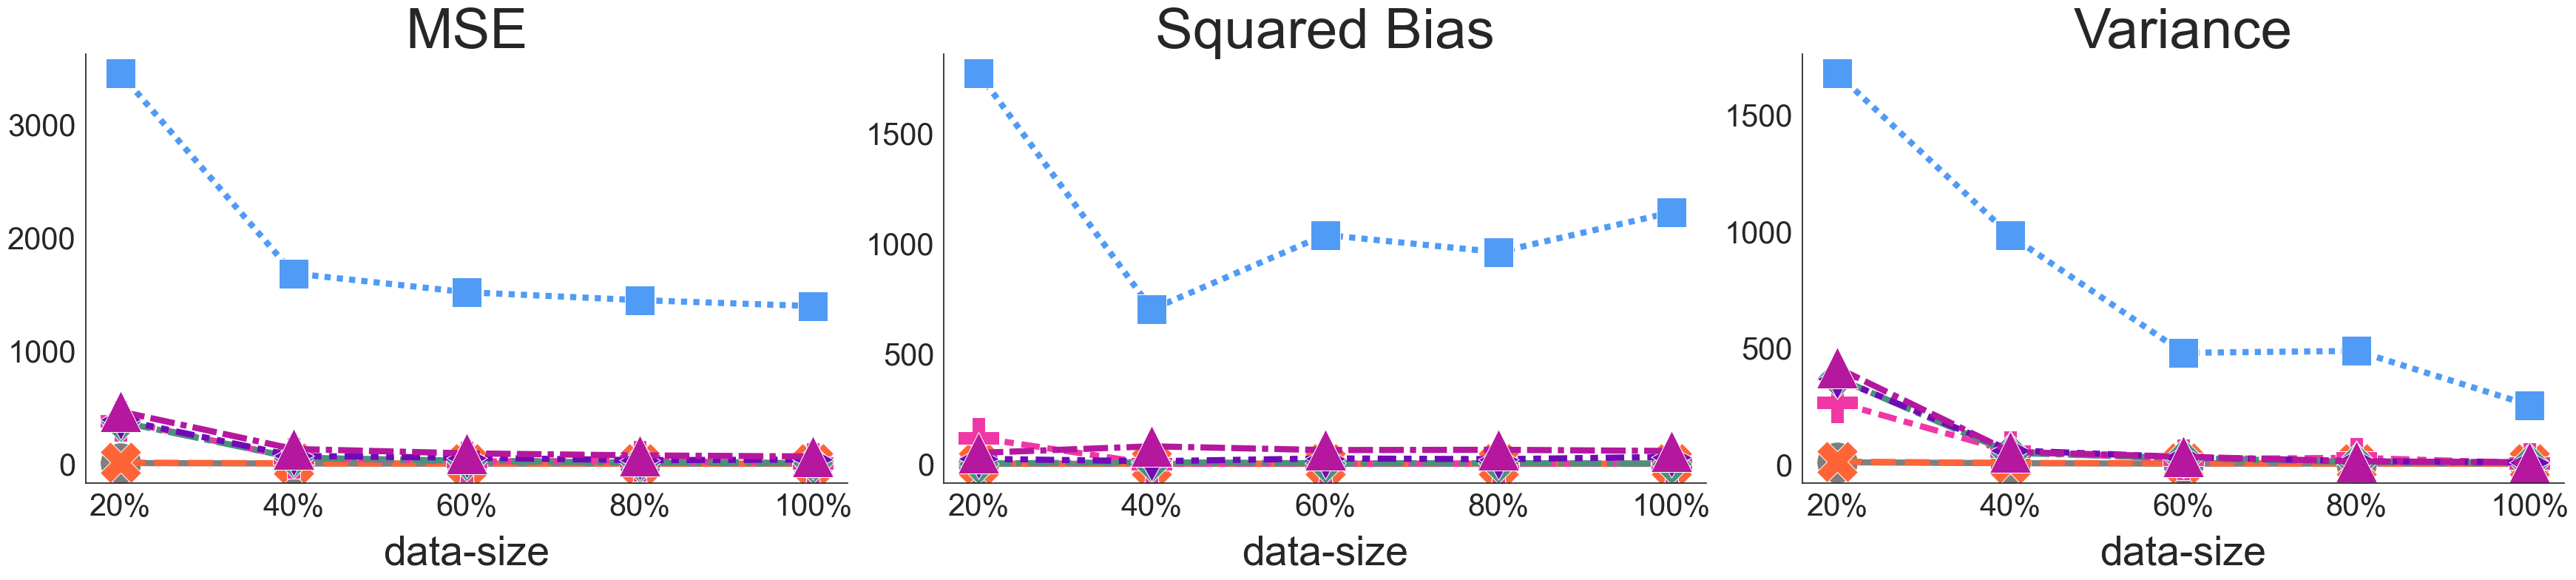

In [25]:
fig, ax_list = plt.subplots(1, 3, figsize=(35, 8), tight_layout=True)
for i, y in enumerate(["se", "bias", "variance"]):
    ax = ax_list[i]
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    sns.lineplot(
        markers=True,
        markersize=40,
        linewidth=6,
        legend=False,
        style="est",
        x="ratio",
        y=y,
        hue="est",
        hue_order=method_list,    # 🌟最重要：パレットの色とmethod_listの順番を厳密に完全同期させる！
        style_order=method_list,  # 🌟最重要：マーカー（スタイル）の順番も固定する！
        ax=ax,
        ci=None,
        palette=palette,
        data=result_df,
    )
    ax.set_title(y_label_dict[y], fontsize=55)
    # yaxis
    ax.set_ylabel("")
    ax.tick_params(axis="y", labelsize=30)
    # xaxis
    ax.set_xlabel("data-size", fontsize=40)
    ax.set_xticks(percentages)
    ax.set_xticklabels([f"{int(p * 100)}%" for p in percentages], fontsize=30)
    ax.xaxis.set_label_coords(0.5, -0.12)